In [4]:
import pandas as pd

df = pd.read_csv('Unemployment_Rate_upto_11_2020.csv')
print(df.head())
print(df.columns.tolist())

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-01-2020          M                              5.48   
1  Andhra Pradesh   29-02-2020          M                              5.83   
2  Andhra Pradesh   31-03-2020          M                              5.79   
3  Andhra Pradesh   30-04-2020          M                             20.51   
4  Andhra Pradesh   31-05-2020          M                             17.43   

    Estimated Employed   Estimated Labour Participation Rate (%) Region.1  \
0             16635535                                     41.02    South   
1             16545652                                     40.90    South   
2             15881197                                     39.18    South   
3             11336911                                     33.10    South   
4             12988845                                     36.46    South   

   longitude  latitude  
0    15.9129     79.74  
1    15.9129

Date range: 2020-01-31 to 2020-10-31

Missing values:
 Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Zone                                       0
longitude                                  0
latitude                                   0
Month                                      0
dtype: int64


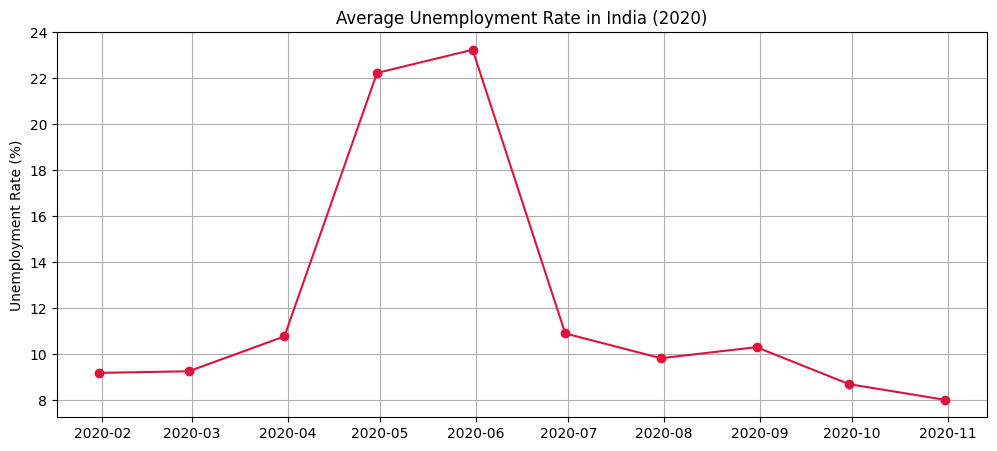


Pre-lockdown (Jan-Mar 2020): 9.76%
Lockdown (Apr-Jun 2020):     18.75%
Jump: +8.99 percentage points (~92% higher)


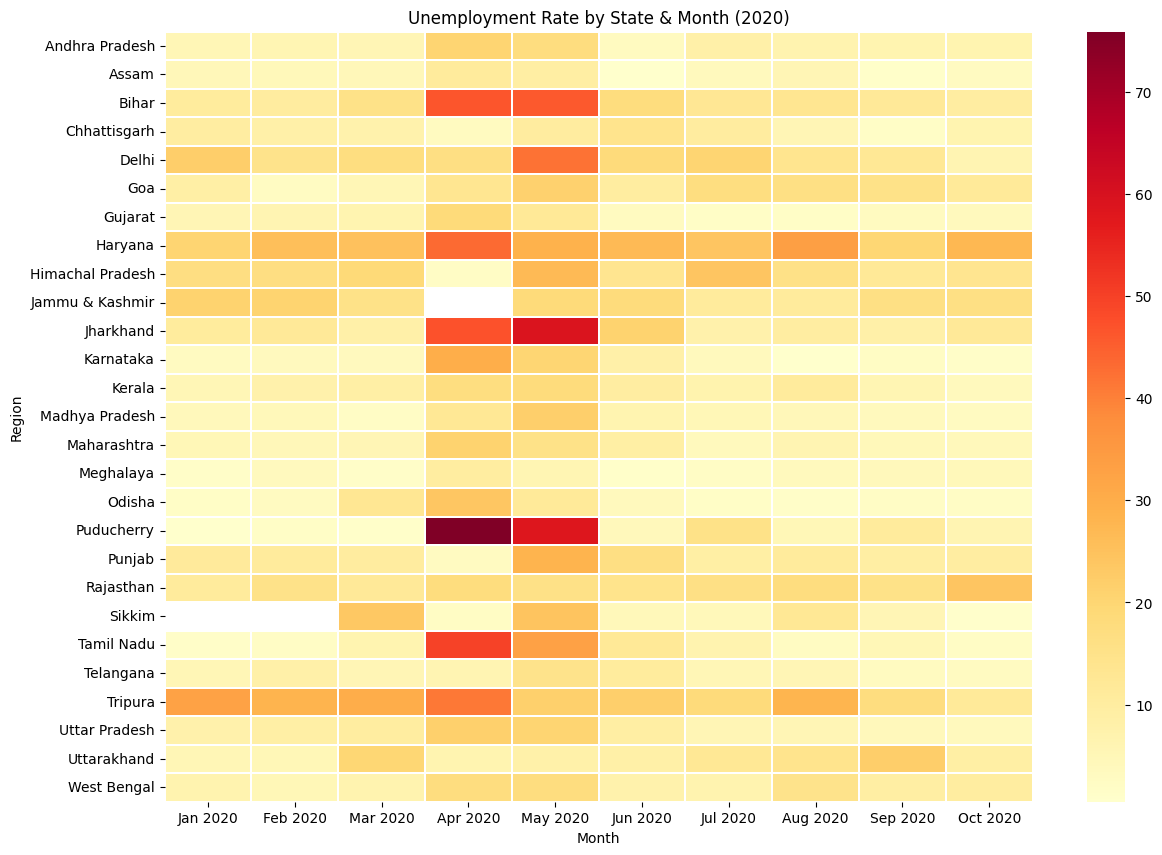


Top 5 worst-hit states (Apr-Jun 2020):
 Region
Puducherry    46.093333
Jharkhand     42.423333
Bihar         36.806667
Haryana       32.980000
Tamil Nadu    31.730000
Name: Estimated Unemployment Rate (%), dtype: float64


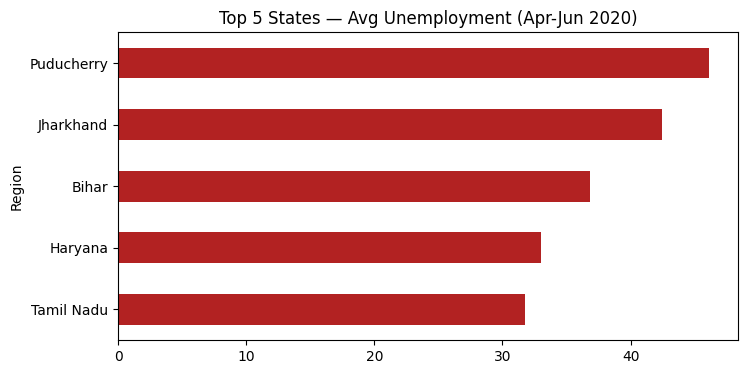

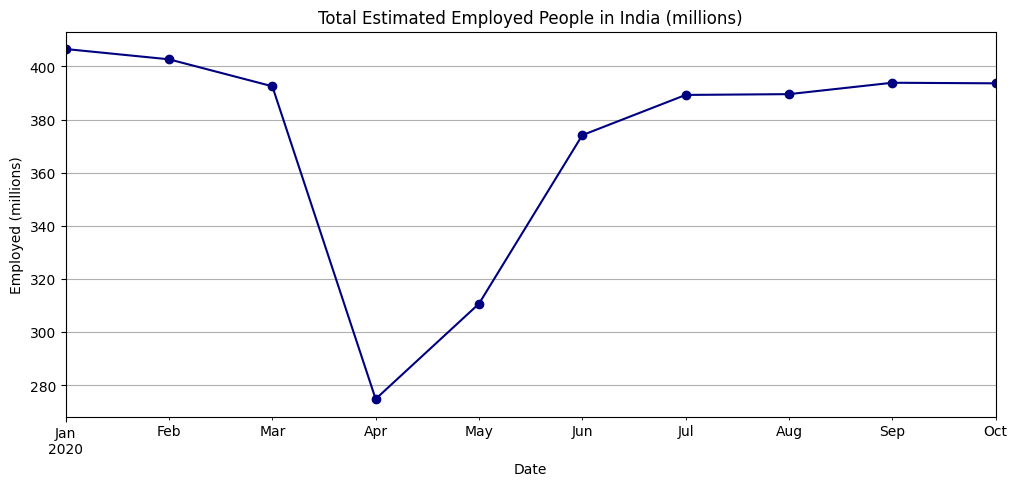

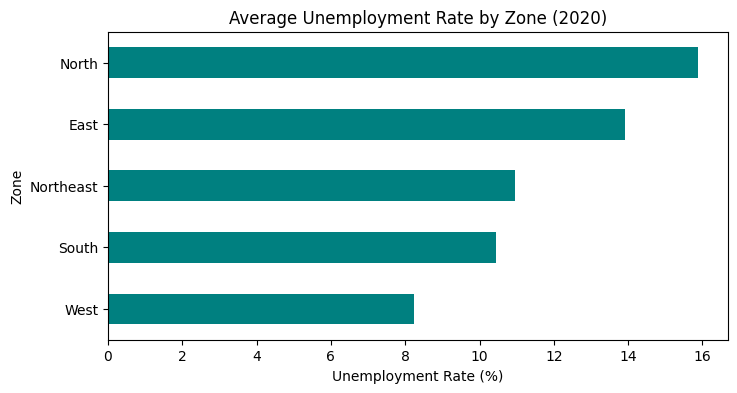

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load & clean
df = pd.read_csv('Unemployment_Rate_upto_11_2020.csv')
df.columns = df.columns.str.strip()            # fix ' Date' -> 'Date' etc.
df = df.rename(columns={'Region.1': 'Zone'})   # Region.1 = North/South/East/West
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Month'] = df['Date'].dt.strftime('%b %Y')

rate = 'Estimated Unemployment Rate (%)'
print("Date range:", df['Date'].min().date(), "to", df['Date'].max().date())
print("\nMissing values:\n", df.isnull().sum())

# 2. National trend over 2020
monthly = df.groupby('Date')[rate].mean().reset_index()
plt.figure(figsize=(12,5))
plt.plot(monthly['Date'], monthly[rate], marker='o', color='crimson')
plt.title('Average Unemployment Rate in India (2020)')
plt.ylabel('Unemployment Rate (%)'); plt.grid(True)
plt.savefig('trend.png', bbox_inches='tight'); plt.show()

# 3. Covid-19 impact: Jan-Mar (pre-lockdown) vs Apr-Jun (lockdown)
pre  = df[df['Date'] <= '2020-03-31'][rate].mean()
lock = df[(df['Date'] >= '2020-04-01') & (df['Date'] <= '2020-06-30')][rate].mean()
print(f"\nPre-lockdown (Jan-Mar 2020): {pre:.2f}%")
print(f"Lockdown (Apr-Jun 2020):     {lock:.2f}%")
print(f"Jump: +{lock - pre:.2f} percentage points (~{(lock/pre - 1)*100:.0f}% higher)")

# 4. Heatmap: state vs month
pivot = df.pivot_table(values=rate, index='Region', columns='Month', aggfunc='mean')
order = ['Jan 2020','Feb 2020','Mar 2020','Apr 2020','May 2020','Jun 2020',
         'Jul 2020','Aug 2020','Sep 2020','Oct 2020','Nov 2020']
pivot = pivot[[m for m in order if m in pivot.columns]]
plt.figure(figsize=(14,10))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3)
plt.title('Unemployment Rate by State & Month (2020)')
plt.savefig('heatmap.png', bbox_inches='tight'); plt.show()

# 5. Worst-hit states during lockdown
lock_df = df[(df['Date'] >= '2020-04-01') & (df['Date'] <= '2020-06-30')]
top5 = lock_df.groupby('Region')[rate].mean().sort_values(ascending=False).head(5)
print("\nTop 5 worst-hit states (Apr-Jun 2020):\n", top5)
top5.plot(kind='barh', color='firebrick', figsize=(8,4),
          title='Top 5 States — Avg Unemployment (Apr-Jun 2020)')
plt.gca().invert_yaxis()
plt.savefig('top5.png', bbox_inches='tight'); plt.show()

# 6. People employed: the lockdown dip
emp = df.groupby('Date')['Estimated Employed'].sum() / 1e6
emp.plot(marker='o', figsize=(12,5), color='navy',
         title='Total Estimated Employed People in India (millions)')
plt.ylabel('Employed (millions)'); plt.grid(True)
plt.savefig('employed.png', bbox_inches='tight'); plt.show()

# 7. Zone comparison
zone = df.groupby('Zone')[rate].mean().sort_values()
zone.plot(kind='barh', color='teal', figsize=(8,4),
          title='Average Unemployment Rate by Zone (2020)')
plt.xlabel('Unemployment Rate (%)')
plt.savefig('zones.png', bbox_inches='tight'); plt.show()